# Sentiment Analysis — Amazon Fitness Clothing Reviews

## Objective
Analyze customer sentiment from Amazon product reviews scraped 
in Task 1 using Natural Language Processing (NLP).

## Approach
- Extracted 1080 individual reviews from 224 products
- Used TextBlob library to calculate polarity scores
- Classified reviews as Positive, Neutral or Negative
- Visualized sentiment distribution and polarity scores

## Results
- Positive reviews: 585 (54%)
- Neutral reviews: 451 (42%)
- Negative reviews: 44 (4%)

## Key Insights
- Overall customer sentiment is positive
- Non-English reviews defaulted to Neutral (TextBlob limitation)
- Informal expressions like "Hubby loves them!" were missed
- Only 4% negative reviews suggesting good product quality

## Libraries Used
- `TextBlob` — sentiment analysis and polarity scoring
- `pandas` — data manipulation
- `matplotlib` & `seaborn` — visualization

## Dataset
1080 reviews scraped from Amazon fitness clothing products

In [14]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv(r"C:\Users\dawoo\OneDrive\David Drive\Code Alpha Internship\1(B)-Web Scraping\5-amazon_products.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few reviews:")
print(df['Customer Reviews'].head())

Shape: (224, 13)

Columns: ['Product Name', 'Current Price', 'Typical Price', 'Rating', 'Total Reviews', 'Delivery Charges', 'Fabric Type', 'Care Instructions', 'Origin', 'Customer Reviews', 'Currency', 'Discount Amount', 'Discount Percent']

First few reviews:
0    {'Hubby loves them!': '5 out of 5 stars', 'Per...
1    {'Passt die Größe': '3 out of 5 stars', 'Gym':...
2    {'Super zum Abnehmen': '5 out of 5 stars', 'Bo...
3    {'Good': '5 out of 5 stars', 'Valor Precio': '...
4    {'Value for money!': '5 out of 5 stars', 'Well...
Name: Customer Reviews, dtype: str


In [16]:
import ast

# Drop rows where Customer Reviews is NaN
df = df.dropna(subset=['Customer Reviews'])

# Convert string to actual dictionary
df['Customer Reviews'] = df['Customer Reviews'].apply(ast.literal_eval)

# Extract just the review titles (keys of dictionary)
df['review_list'] = df['Customer Reviews'].apply(lambda x: list(x.keys()))

# Explode so each review becomes its own row
reviews_df = df[['Product Name', 'review_list']].explode('review_list')
reviews_df.columns = ['Product Name', 'Review']

# Remove empty reviews
reviews_df = reviews_df[reviews_df['Review'].str.strip() != '']

print("Total individual reviews:", len(reviews_df))
print("\nSample reviews:")
print(reviews_df['Review'].head(10))

Total individual reviews: 1080

Sample reviews:
0                                    Hubby loves them!
0    Perfect combination of fit, comfort and breath...
0    Great lightweight workout shirt - picking up m...
0                                              to thin
0                                       Nice tee shirt
0                         Men's Moisture Wicking Shirt
0               Comfortable, Durable, and Well-Fitting
0                           very light and comfortable
1                                      Passt die Größe
1                                                  Gym
Name: Review, dtype: str


In [17]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity
    
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

# Apply to all reviews
reviews_df['Sentiment'] = reviews_df['Review'].apply(get_sentiment)
reviews_df['Polarity'] = reviews_df['Review'].apply(get_polarity)

print("Sentiment Distribution:")
print(reviews_df['Sentiment'].value_counts())
print("\nSample results:")
print(reviews_df[['Review', 'Sentiment', 'Polarity']].head(10))

Sentiment Distribution:
Sentiment
Positive    585
Neutral     451
Negative     44
Name: count, dtype: int64

Sample results:
                                              Review Sentiment  Polarity
0                                  Hubby loves them!   Neutral    0.0000
0  Perfect combination of fit, comfort and breath...  Positive    0.7000
0  Great lightweight workout shirt - picking up m...  Positive    0.7125
0                                            to thin  Negative   -0.4000
0                                     Nice tee shirt  Positive    0.6000
0                       Men's Moisture Wicking Shirt   Neutral    0.0000
0             Comfortable, Durable, and Well-Fitting  Positive    0.4000
0                         very light and comfortable  Positive    0.4600
1                                    Passt die Größe   Neutral    0.0000
1                                                Gym   Neutral    0.0000


In [18]:
reviews_df

,Product Name,Review,Sentiment,Polarity
0,MAGCOMSEN Men's Short Sleeve Moisture Wicking ...,Hubby loves them!,Neutral,0.000000
0,MAGCOMSEN Men's Short Sleeve Moisture Wicking ...,"Perfect combination of fit, comfort and breath...",Positive,0.700000
0,MAGCOMSEN Men's Short Sleeve Moisture Wicking ...,Great lightweight workout shirt - picking up m...,Positive,0.712500
0,MAGCOMSEN Men's Short Sleeve Moisture Wicking ...,to thin,Negative,-0.400000
0,MAGCOMSEN Men's Short Sleeve Moisture Wicking ...,Nice tee shirt,Positive,0.600000
...,...,...,...,...
223,CANGHPGIN Mens Workout Athletic Shorts 7 inch ...,"decent pants, good for running on a hot day",Positive,0.372222
223,CANGHPGIN Mens Workout Athletic Shorts 7 inch ...,Love them,Positive,0.500000
223,CANGHPGIN Mens Workout Athletic Shorts 7 inch ...,Ok,Positive,0.500000
223,CANGHPGIN Mens Workout Athletic Shorts 7 inch ...,Great comfort,Positive,0.800000


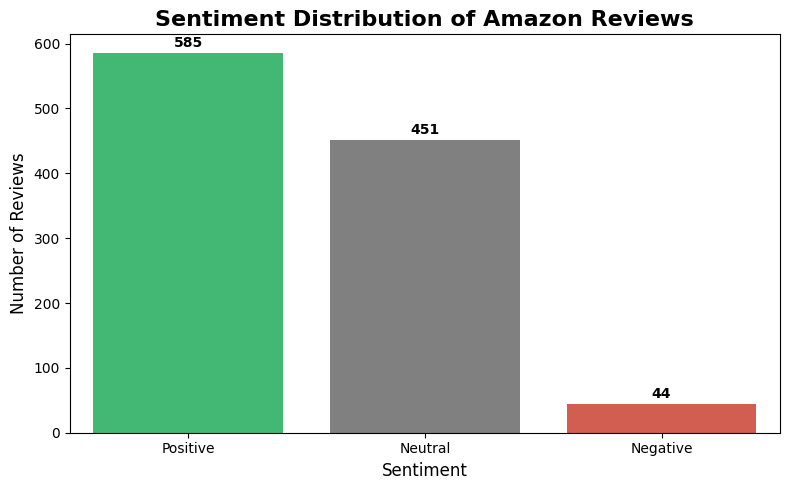

In [19]:
plt.figure(figsize=(8, 5))

sentiment_counts = reviews_df['Sentiment'].value_counts()
colors = ['#E50914', '#221F1F', '#808080']

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    hue=sentiment_counts.index,
    palette=['#2ecc71', '#808080', '#e74c3c'],
    legend=False
)

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=10, fontweight='bold')

plt.title('Sentiment Distribution of Amazon Reviews', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.tight_layout()
plt.savefig('chart6_sentiment_distribution.png', dpi=150)
plt.show()

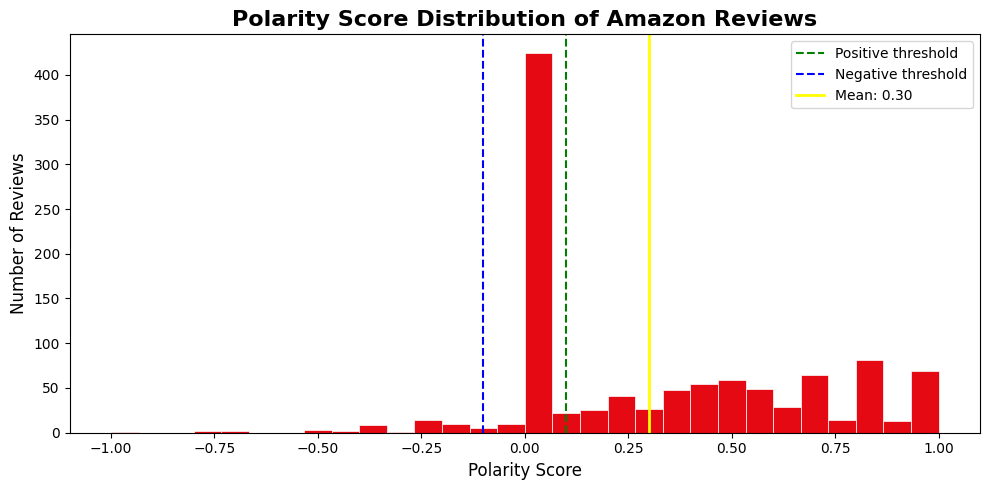

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    reviews_df['Polarity'],
    bins=30,
    color='#E50914',
    edgecolor='white',
    linewidth=0.5
)

plt.axvline(x=0.1, color='green', linestyle='--', linewidth=1.5, label='Positive threshold')
plt.axvline(x=-0.1, color='blue', linestyle='--', linewidth=1.5, label='Negative threshold')
plt.axvline(x=reviews_df['Polarity'].mean(), color='yellow', linestyle='-', linewidth=2, label=f'Mean: {reviews_df["Polarity"].mean():.2f}')

plt.title('Polarity Score Distribution of Amazon Reviews', fontsize=16, fontweight='bold')
plt.xlabel('Polarity Score', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('chart7_polarity_distribution.png', dpi=150)
plt.show()